# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**


----

# Trabajo práctico entregable - parte 1


Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
seaborn.set_context('talk')

In [3]:
# Cargamos los datos
melb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')

print(f"Tamaño: {melb_df.shape[0]} filas, {melb_df.shape[1]} columnas")
melb_df.describe()

Tamaño: 13580 filas, 21 columnas


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [4]:
# Copia de la base de datos original como back up
melb_data = melb_df.copy()

### Información acerca de las variables
Suburb: Suburb

Address: Dirección

Rooms: Número de habitaciones

Price: Precio en dólares australianos

Method:
S - propiedad vendida;
SP - propiedad vendida previamente;
PI - propiedad no vendida (pasó en subasta sin alcanzar el precio de reserva);
PN - vendida previamente no divulgada;
SN - vendida no divulgada;
NB - sin oferta;
VB - oferta del vendedor;
W - retirada antes de la subasta;
SA - vendida después de la subasta;
SS - vendida después de la subasta (precio no divulgado).
N/A - precio o oferta más alta no disponible.

Type:
br - dormitorio(s);
h - casa, cabaña, villa, semi-adosado, terraza;
u - unidad, dúplex;
t - casa adosada;
dev site - sitio de desarrollo;
o res - otra residencia.

SellerG: Agente inmobiliario

Date: Fecha de venta

Distance: Distancia al CBD en kilómetros

Regionname: Región general (Oeste, Noroeste, Norte, Noreste, etc.)

Propertycount: Número de propiedades existentes en el suburbio.

Bedroom2 : Número de dormitorios (obtenido de otra fuente)

Bathroom: Número de baños

Car: Número de plazas de aparcamiento

Landsize: Tamaño del terreno en metros cuadrados

BuildingArea: Superficie construida en metros cuadrados

YearBuilt: Año de construcción de la casa

CouncilArea: Área del consejo municipal

Lattitude: Latitud

Longtitude: Longitud


In [5]:
melb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos, **excepto** `BuildingArea` y `YearBuilt`.

2. Decidir si elimina algunas filas o columnas en base al análisis de datos faltantes.

3. Hacer un análisis descriptivo de las variables numéricas del conjunto de datos. Todas tienen el tipo `Dtype` correcto asignado? Armar una matriz (array) sólo con las variables numéricas.  

4. Estudiar las variables categóricas del DataFrame. Aplicar una codificación One-hot encoding a las columnas categóricas que crea pertinente. Si lo consideran necesario, pueden reducir el número de categorías únicas de algunas variables. ¿Cómo trataría la variable `Date`? Armar la matriz de variables categóricas codificada.

5. Concatenar la matriz de variables numéricas a la matriz que codifica las variables categóricas resultante del punto anterior.

Algunas opciones:
  1. Utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas.
  2. `DictVectorizer` con algunos pasos de pre-proceso previo.

Recordar también que el atributo `pandas.DataFrame.values` permite acceder a la matriz de numpy subyacente a un DataFrame.


###Resolución
Tal como se indica en la primer consigna se procede a seleccionar filas y columnas de la base de datos (exceptuando `BuildingArea` y `YearBuilt`).

In [6]:
columnas_excluidas = ['BuildingArea', 'YearBuilt']
melb_df = melb_df.drop(columns=columnas_excluidas)

A continuación se va a realizar un análisis del conjunto de datos con el fin de identificar posibles datos faltantes.

In [7]:
# Datos faltantes
datos_faltantes = melb_df.isna().sum()
datos_faltantes[datos_faltantes > 0]
pct_faltantes = ((datos_faltantes / len(melb_df)) * 100).round(2)

faltantes_df = pd.DataFrame({
    'Columnas': datos_faltantes.index,
    'Faltantes': datos_faltantes.values,
    'Porcentaje': pct_faltantes.values
    }).sort_values('Faltantes', ascending=False)

faltantes_df

,Columnas,Faltantes,Porcentaje
14,CouncilArea,1369,10.08
12,Car,62,0.46
0,Suburb,0,0.00
2,Rooms,0,0.00
1,Address,0,0.00
3,Type,0,0.00
4,Price,0,0.00
7,Date,0,0.00
8,Distance,0,0.00
5,Method,0,0.00


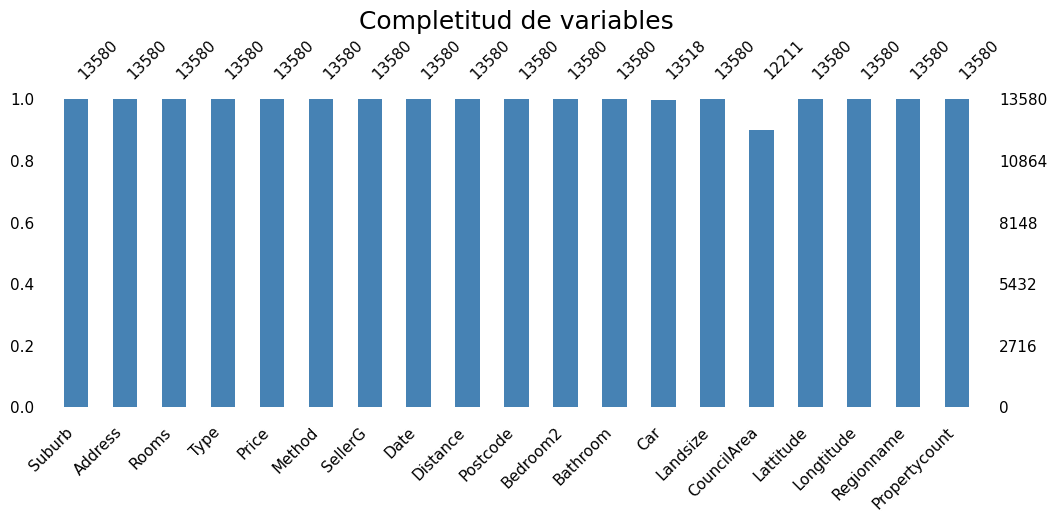

In [ ]:
import matplotlib.pyplot as plt
import missingno as msno

# Visualización con missingno
msno.bar(melb_df, figsize=(12, 4), fontsize=11, color='steelblue')
plt.title("Completitud de variables")
plt.show()

Teniendo ahora el peso relativo de los valores nulos se observa que _CouncilArea_ tiene un 10% de datos faltantes. No puede imputarse con KNN sin hacer encoding previo por lo que **se decide eliminar esta columna**.

Por otro lado,la variable _Car_ que también tiene datos faltantes pero que representan el 0,5% del total. **Se eliminan las 62 filas faltantes solamente.**

In [8]:
# 1) Eliminar la columna CouncilArea
melb_df = melb_df.drop('CouncilArea', axis=1)

# 2) Eliminar filas con Car = NaN
melb_df.dropna(subset=['Car'], how='any', inplace=True)

# Verificar que no quedan faltantes
print(f"\nFaltantes restantes: {melb_df.isna().sum().sum()}")


Faltantes restantes: 0


Según la consigna ahora corresponde realizar un análisis descriptivo de la vairables numéricas, verificando que este asignado correctamente el `Dtype`.

In [9]:
columnas_num = melb_df.select_dtypes(include=[np.number]).columns.tolist()
columnas_categ = melb_df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas: {columnas_num}")
print(f"Variables categóricas: {columnas_categ}")

print("\nDescripción de variables numéricas")
melb_df[columnas_num].describe()

Variables numéricas: ['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'Propertycount']
Variables categóricas: ['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'Regionname']

Descripción de variables numéricas


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,Propertycount
count,13518.000000,1.351800e+04,13518.000000,13518.000000,13518.000000,13518.00000,13518.000000,13518.000000,13518.000000,13518.000000,13518.000000
mean,2.939784,1.074796e+06,10.157827,3105.227401,2.916408,1.53536,1.610075,558.110593,-37.809191,144.995306,7455.482986
std,0.956438,6.398586e+05,5.861593,90.724572,0.966692,0.69231,0.962634,3998.194560,0.079366,0.104003,4381.437721
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.00000,0.000000,0.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.200000,3044.000000,2.000000,1.00000,1.000000,178.000000,-37.857000,144.929425,4380.000000
50%,3.000000,9.010000e+05,9.200000,3084.000000,3.000000,1.00000,2.000000,442.500000,-37.802300,145.000300,6567.000000
75%,3.000000,1.328000e+06,13.000000,3148.000000,3.000000,2.00000,2.000000,651.000000,-37.756203,145.058600,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.00000,10.000000,433014.000000,-37.408530,145.526350,21650.000000


In [10]:
# Verificación de los Dtype de la variables.
melb_df.dtypes.to_frame('dtype').assign(
    ejemplo=melb_df.iloc[0]
)

,dtype,ejemplo
Suburb,object,Abbotsford
Address,object,85 Turner St
Rooms,int64,2
Type,object,h
Price,float64,1480000.0
Method,object,S
SellerG,object,Biggin
Date,object,3/12/2016
Distance,float64,2.5
Postcode,float64,3067.0


La variable `Date` contiene fechas en formato `object` (string: día/mes/año) que representan la fecha de venta de cada propiedad. El tipo correcto sería `datetime`.

In [11]:
# Matriz de variables numéricas
matriz_num = melb_df[columnas_num].values

print(f"Matriz numérica: {matriz_num.shape}")
print(f"{matriz_num.shape[0]} propiedades | {matriz_num.shape[1]} características numéricas")

Matriz numérica: (13518, 11)
13518 propiedades | 11 características numéricas


Ahora el enfoque del análisis se hace en las variables categóricas.

In [12]:
# Valores únicos por variable categórica
for col in columnas_categ:
    print(f"{col}: {melb_df[col].nunique()} valores únicos")

Suburb: 314 valores únicos
Address: 13318 valores únicos
Type: 3 valores únicos
Method: 5 valores únicos
SellerG: 268 valores únicos
Date: 58 valores únicos
Regionname: 8 valores únicos


Dado que `Date` se encuentra en forma de string y aporta información temporal que ya se encuentra en `YearBuilt` (la cuál se incorpora en el ejercicio siguiente), se toma la decisión de descartarla para simplificar el data frame.

Por otra parte, `Address` tiene una cardinalidad altísima (prácticamente un valor único por propiedad), por lo que aplicar One-Hot Encoding sobre ella generaría miles de columnas (explosión dimensional) sin aportar información generalizable para el modelo. **Se decide eliminar también esta variable.**

In [13]:
# Eliminar Date y Address (alta cardinalidad)
melb_df = melb_df.drop(columns=['Date', 'Address'])
columnas_categ.remove('Date')
columnas_categ.remove('Address')

print(f"Categóricas restantes: {columnas_categ}")

Categóricas restantes: ['Suburb', 'Type', 'Method', 'SellerG', 'Regionname']


Dado que `Suburb` (300 valores) y `SellerG` (200 valores) tienen demasiadas categorías para hacer One-Hot Encoding directo. Se conservans las más frecuentes y se agrupa el resto en 'Otros'. Esta acción evita tener problemas con la dimensionalidad.

In [14]:
print("Antes:")
for col in ['Suburb', 'SellerG']:
    print(f"  {col}: {melb_df[col].nunique()} valores")

# Suburb: top 50 categorías
top_suburbs = melb_df['Suburb'].value_counts().head(50).index
melb_df['Suburb'] = melb_df['Suburb'].apply(lambda x: x if x in top_suburbs else 'Otros')

# SellerG: top 10 categorías
top_sellers = melb_df['SellerG'].value_counts().head(10).index
melb_df['SellerG'] = melb_df['SellerG'].apply(lambda x: x if x in top_sellers else 'Otros')

print("\nDespués:")
for col in ['Suburb', 'SellerG']:
    print(f"  {col}: {melb_df[col].nunique()} valores")

Antes:
  Suburb: 314 valores
  SellerG: 268 valores

Después:
  Suburb: 51 valores
  SellerG: 11 valores


Ahora se utiliza _OneHotEncoder_ de _Scikit-learn_. El parámetro `sparse_output=False` devuelve una matriz densa (numpy array) en lugar de
una matriz esparsa, lo que facilita la concatenación posterior.

In [15]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoder.fit(melb_df[columnas_categ])

matriz_categ = encoder.transform(melb_df[columnas_categ])

encoding_categ = encoder.get_feature_names_out(columnas_categ)

print(f"Matriz categórica (one-hot): {matriz_categ.shape}")
print(f"  → {matriz_categ.shape[1]} columnas generadas")
print(f"\nNombres de categorías: {list(encoding_categ[:6])}")

Matriz categórica (one-hot): (13518, 78)
  → 78 columnas generadas

Nombres de categorías: ['Suburb_Armadale', 'Suburb_Ascot Vale', 'Suburb_Balwyn', 'Suburb_Balwyn North', 'Suburb_Bentleigh', 'Suburb_Bentleigh East']


Seguidamente se realiza la concatenación de matrices. Se utiliza _numpy.hstack_.

In [16]:
matriz_combinada = np.hstack([matriz_num, matriz_categ])

columnas = columnas_num + list(encoding_categ)

print(f"Matriz combinada: {matriz_combinada.shape}")
print(f"  → {matriz_num.shape[1]} numéricas + {matriz_categ.shape[1]} one-hot = {matriz_combinada.shape[1]} total")
print(f"  → {matriz_combinada.shape[0]} propiedades")

Matriz combinada: (13518, 89)
  → 11 numéricas + 78 one-hot = 89 total
  → 13518 propiedades


## Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer`, entre otros, para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.

In [17]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer

###Resolución
En consecuencia con la primer consigna de este ejercicio se procede a agregar _BuildingArea_ y _YearBuilt_ con el fin de imputar sus datos faltantes.

In [18]:
area_construccion = melb_data.loc[melb_df.index, 'BuildingArea'].values
anio_construccion = melb_data.loc[melb_df.index, 'YearBuilt'].values

matriz_extendida = np.column_stack([matriz_combinada, area_construccion, anio_construccion])

columnas_extendidas = columnas + ['BuildingArea', 'YearBuilt']

print(f"Faltantes en BuildingArea: {np.isnan(area_construccion).sum()}")
print(f"Faltantes en YearBuilt:    {np.isnan(anio_construccion).sum()}")
print(f"Matriz extendida: {matriz_extendida.shape}")

Faltantes en BuildingArea: 6417
Faltantes en YearBuilt:    5344
Matriz extendida: (13518, 91)


Seguidamente se realiza la imputación con `IterativeImputer`. Este método itera: en cada paso usa los valores ya imputados (o conocidos) de todas las variables para predecir los faltantes de una columna, y repite el proceso hasta converger.

Es necesario escalar las variables para no introducir sesgos dado que KNN necesita que los datos estén normalizados. Para esto se utiliza _MinMaxScaler_.

In [19]:
from sklearn.preprocessing import MinMaxScaler

# Con MinMaxScaler se escala todas las variables al rango [0, 1]
escalador_knn = MinMaxScaler()
matriz_escalada = escalador_knn.fit_transform(matriz_extendida)

print(f"Rango resultante (ignorando NaN):")
print(f"  Min: {np.nanmin(matriz_escalada):.4f}")
print(f"  Max: {np.nanmax(matriz_escalada):.4f}")
print(f"  NaN presentes: {np.isnan(matriz_escalada).sum()}")

Rango resultante (ignorando NaN):
  Min: 0.0000
  Max: 1.0000
  NaN presentes: 11761


In [20]:
# IterativeImputer con KNeighborsRegressor.
# n_neighbors=5 es un valor estándar; max_iter=5 es suficiente para convergencia
# en este dataset y mantiene el consumo de memoria acotado.
imputador = IterativeImputer(
    estimator=KNeighborsRegressor(n_neighbors=5),
    max_iter=5,
    random_state=42
)

matriz_imputada = imputador.fit_transform(matriz_escalada)

# Revertir el escalado MinMax para tener los valores en su escala original
matriz_imputada_original = escalador_knn.inverse_transform(matriz_imputada)

print(f"Imputación completada.")
print(f"NaN restantes: {np.isnan(matriz_imputada).sum()}")
print(f"Matriz imputada (escala original): {matriz_imputada_original.shape}")

Imputación completada.
NaN restantes: 0
Matriz imputada (escala original): (13518, 91)


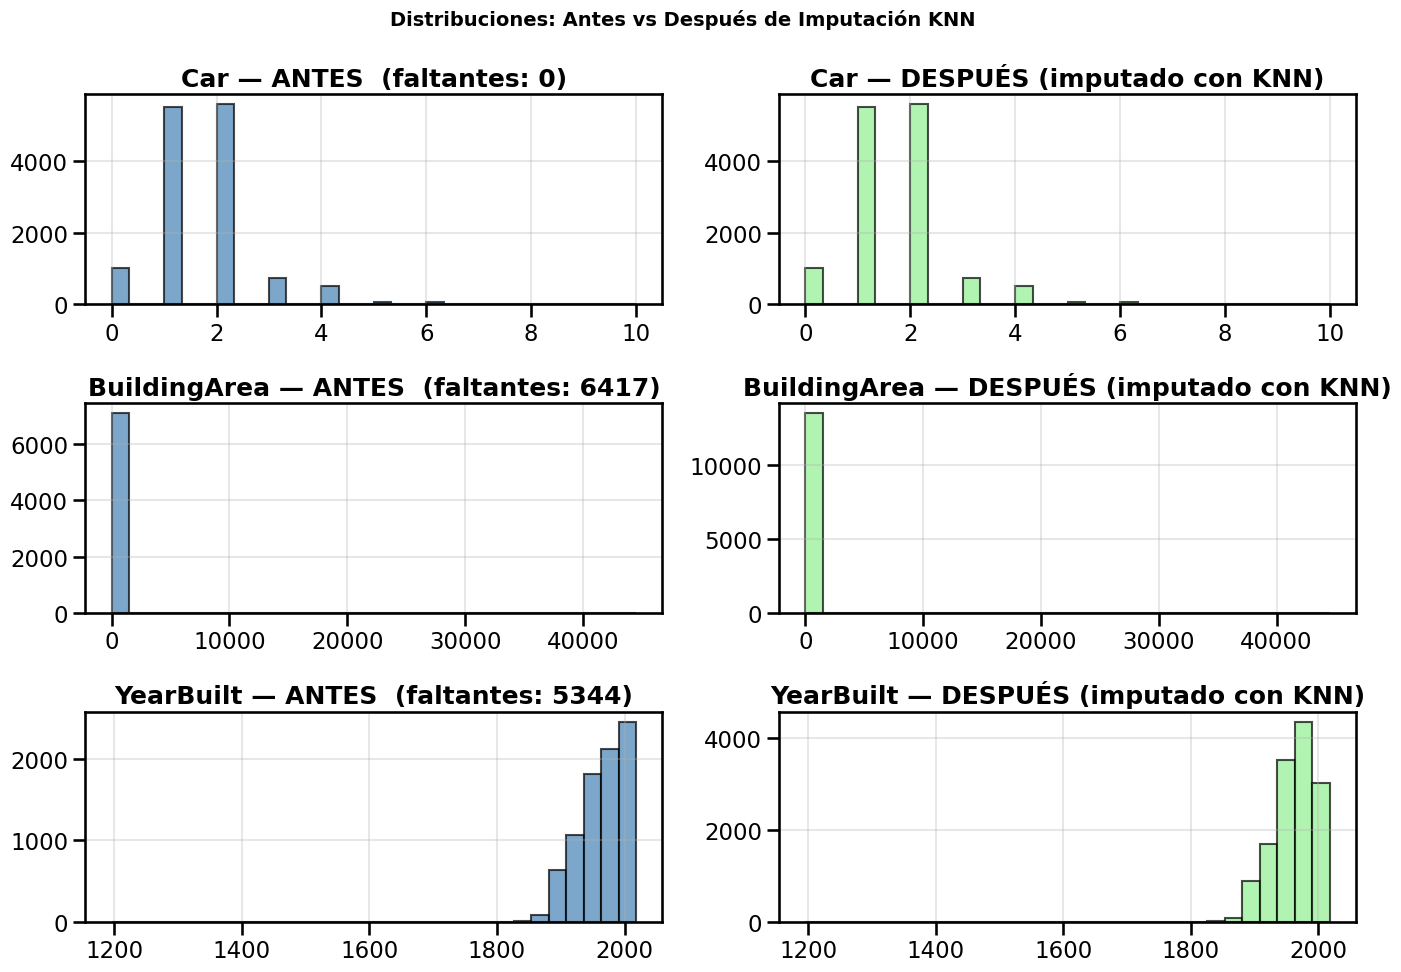

In [21]:
vars_comparar = ['Car', 'BuildingArea', 'YearBuilt']

fig, axes = plt.subplots(len(vars_comparar), 2, figsize=(14, 10))
fig.suptitle('Distribuciones: Antes vs Después de Imputación KNN', fontsize=14, fontweight='bold')

for idx, var in enumerate(vars_comparar):
    col_idx = columnas_extendidas.index(var)

    # Antes (escala original con NaN)
    datos_antes = matriz_extendida[:, col_idx]
    validos = ~np.isnan(datos_antes)
    axes[idx, 0].hist(datos_antes[validos], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx, 0].set_title(f'{var} — ANTES  (faltantes: {(~validos).sum()})', fontweight='bold')
    axes[idx, 0].grid(alpha=0.3)

    # Después (escala original, sin NaN)
    datos_despues = matriz_imputada_original[:, col_idx]
    axes[idx, 1].hist(datos_despues, bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
    axes[idx, 1].set_title(f'{var} — DESPUÉS (imputado con KNN)', fontweight='bold')
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos? Puede decidir si hacer PCA sobre todas las variables o bien seleccionar un subconjunto que crea pertinente.

2. Seleccione las proyecciones de los datos sobre las dos primeras componentes principales (las primeras dos columnas del resultado) para agregar como nuevas características al conjunto de datos.

### Resolución
PCA busca las direcciones de máxima varianza en los datos. Si las variables tienen escalas muy diferentes, las de mayor magnitud dominarán los componentes principales y distorsionarán el resultado. Por lo tanto, **es necesario estandarizar los datos previamente**.

Para PCA se prefiere `StandardScaler` sobre `MinMaxScaler` porque centra los datos (media = 0), lo cual es un requisito para que PCA interprete correctamente la varianza alrededor del origen.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Estandarizar los datos imputados antes de aplicar PCA
escalador_pca = StandardScaler()
matriz_estandarizada = escalador_pca.fit_transform(matriz_imputada_original)

print(f"Datos estandarizados.")
print(f"  Media ≈ {matriz_estandarizada.mean():.6f}")
print(f"  Desv.est. ≈ {matriz_estandarizada.std():.4f}")

Datos estandarizados.
  Media ≈ -0.000000
  Desv.est. ≈ 1.0000


Ahora se aplica PCA con `n = min(20, X.shape[0])` componentes principales tal como indica la consigna. Se analiza la varianza explicada por cada componente para entender cuánta información se conserva.

In [23]:
n_componentes = min(20, matriz_estandarizada.shape[0])
pca = PCA(n_components=n_componentes)
matriz_pca = pca.fit_transform(matriz_estandarizada)

varianza_ratio = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_ratio)

print(f"PCA aplicado.")
print(f"  Entrada: {matriz_estandarizada.shape[1]} características")
print(f"  Salida:  {matriz_pca.shape[1]} componentes principales")

print(f"\nVarianza explicada por componente:")
for i in range(5):
    print(f"  PC{i+1}: {varianza_ratio[i]*100:.2f}%")

print(f"\nVarianza acumulada:")
print(f"  Primeras 2:  {varianza_acumulada[1]*100:.2f}%")
print(f"  Primeras 5:  {varianza_acumulada[4]*100:.2f}%")
print(f"  Primeras 10: {varianza_acumulada[9]*100:.2f}%")
print(f"  Primeras 20: {varianza_acumulada[19]*100:.2f}%")

PCA aplicado.
  Entrada: 91 características
  Salida:  20 componentes principales

Varianza explicada por componente:
  PC1: 4.94%
  PC2: 4.26%
  PC3: 3.23%
  PC4: 2.89%
  PC5: 2.14%

Varianza acumulada:
  Primeras 2:  9.20%
  Primeras 5:  17.47%
  Primeras 10: 26.44%
  Primeras 20: 39.91%


Se grafica la varianza explicada y la proyección de los datos sobre las dos primeras componentes principales.

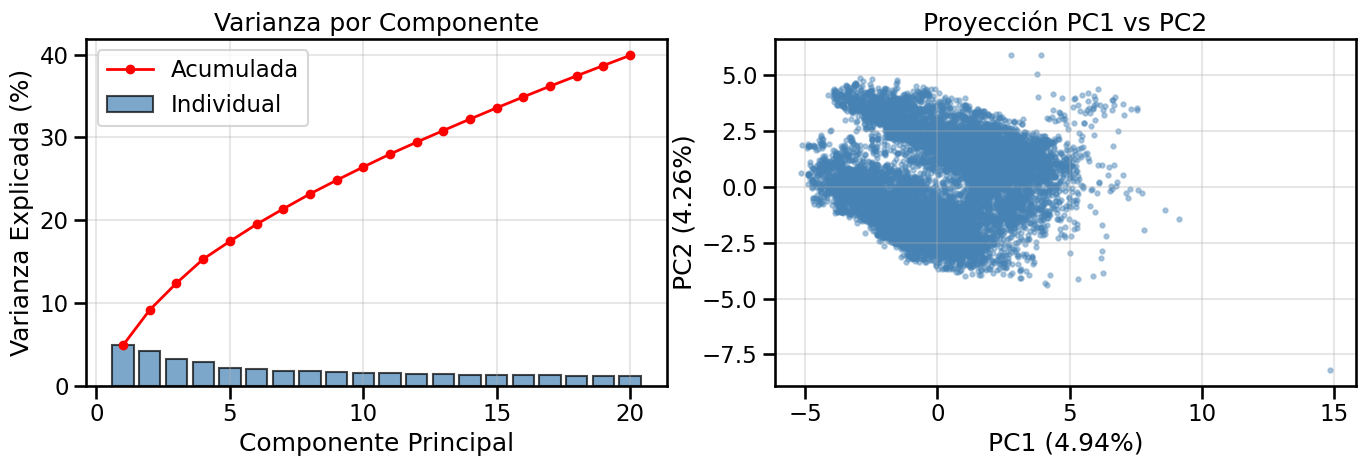

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza individual y acumulada
axes[0].bar(range(1, n_componentes+1), varianza_ratio*100, color='steelblue', alpha=0.7, edgecolor='black', label='Individual')
axes[0].plot(range(1, n_componentes+1), varianza_acumulada*100, 'ro-', linewidth=2, markersize=6, label='Acumulada')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Varianza por Componente')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Proyección en las 2 primeras componentes
axes[1].scatter(matriz_pca[:, 0], matriz_pca[:, 1], alpha=0.4, s=10, color='steelblue')
axes[1].set_xlabel(f'PC1 ({varianza_ratio[0]*100:.2f}%)')
axes[1].set_ylabel(f'PC2 ({varianza_ratio[1]*100:.2f}%)')
axes[1].set_title('Proyección PC1 vs PC2')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Por último, según la segunda consigna del ejercicio, se seleccionan las proyecciones de los datos sobre las dos primeras componentes principales (PC1 y PC2). Estas serán agregadas como nuevas características al conjunto de datos en el Ejercicio 4.

In [25]:
# Seleccionar las dos primeras componentes principales
matriz_pca_2 = matriz_pca[:, :2]

print(f"Componentes seleccionados: PC1 y PC2")
print(f"Shape: {matriz_pca_2.shape}")
print(f"Varianza capturada: {varianza_acumulada[1]*100:.2f}%")

Componentes seleccionados: PC1 y PC2
Shape: (13518, 2)
Varianza capturada: 9.20%


## Ejercicio 4: Composición del resultado

Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

Para eso, será necesario recordar el nombre original de cada columna de la matriz, en el orden correcto. Tener en cuenta:
1. El método `OneHotEncoder.get_feature_names` o el atributo `OneHotEncoder.categories_` permiten obtener una lista con los valores de la categoría que le corresponde a cada índice de la matriz.
2. Ninguno de los métodos aplicados intercambia de lugar las columnas o las filas de la matriz.

### Resolución
Para componer el resultado final hay que recuperar el nombre original de cada columna de la matriz, respetando el orden en que fueron concatenadas. Como indica la consigna, esto es posible porque:

1. El método `OneHotEncoder.get_feature_names_out()` devuelve los nombres generados para cada columna del encoding one-hot (con el formato `<columna>_<categoría>`). El atributo `OneHotEncoder.categories_` contiene la lista de categorías encontradas para cada variable categórica.
2. Ninguno de los métodos aplicados (`OneHotEncoder`, `np.hstack`, `MinMaxScaler`, `IterativeImputer`, `StandardScaler`, `PCA`) intercambia el orden de las columnas ni de las filas de la matriz.

Se reconstruyen los nombres explícitamente desde el `encoder` ajustado en el Ejercicio 1 y se agregan al final las 2 componentes principales PCA_1 y PCA_2.

In [26]:
# Combinar: datos imputados en escala original + 2 componentes PCA
matriz_final = np.column_stack([matriz_imputada_original, matriz_pca_2])

columnas_finales = columnas_extendidas + ['PCA_1', 'PCA_2']

# Crear el DataFrame final
datos_finales = pd.DataFrame(matriz_final, columns=columnas_finales)

print(f"DataFrame final: {datos_finales.shape}")
print(f"  → {datos_finales.shape[0]} propiedades")
print(f"  → {datos_finales.shape[1]} columnas (variables originales + 2 componentes PCA)")
print(f"  → NaN: {datos_finales.isna().sum().sum()}")
datos_finales.head()

DataFrame final: (13518, 93)
  → 13518 propiedades
  → 93 columnas (variables originales + 2 componentes PCA)
  → NaN: 0


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,BuildingArea,YearBuilt,PCA_1,PCA_2
0,2.0,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,-37.7996,144.9984,...,1.0,0.0,0.0,0.0,0.0,0.0,86.4,1933.0,-1.358332,-0.471785
1,2.0,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,-37.8079,144.9934,...,1.0,0.0,0.0,0.0,0.0,0.0,79.0,1900.0,-1.757818,-0.397929
2,3.0,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,-37.8093,144.9944,...,1.0,0.0,0.0,0.0,0.0,0.0,150.0,1900.0,-0.588198,-0.860284
3,3.0,850000.0,2.5,3067.0,3.0,2.0,1.0,94.0,-37.7969,144.9969,...,1.0,0.0,0.0,0.0,0.0,0.0,131.6,1916.6,-0.420454,-0.845370
4,4.0,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,-37.8072,144.9941,...,1.0,0.0,0.0,0.0,0.0,0.0,142.0,2014.0,-0.052474,-1.382040


Por último, se guarda el conjunto de datos procesado en un archivo CSV y se verifica que se haya guardado correctamente realizando una lectura del archivo.

In [27]:
# Guardar el DataFrame final a CSV
archivo_salida = 'melb_data_processed.csv'
datos_finales.to_csv(archivo_salida, index=False)

# Verificar la integridad del archivo guardado
datos_verificacion = pd.read_csv(archivo_salida)
print(f"Archivo guardado: {archivo_salida}")
print(f"Shape verificación: {datos_verificacion.shape}")
print(f"NaN verificación:   {datos_verificacion.isna().sum().sum()}")

Archivo guardado: melb_data_processed.csv
Shape verificación: (13518, 93)
NaN verificación:   0


## Ejercicio 5: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas o columnas
  2. Interpretación de las columnas presentes
  2. Todas las transofrmaciones realizadas

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:

```
  ## Criterios de exclusión de ejemplos
  1. Se eliminan ejemplos donde el año de construcción es previo a 1900

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. ...
  Todas las características categóricas fueron codificadas con un
  método OneHotEncoding utilizando como máximo sus 30 valores más
  frecuentes.
  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Distance: Distancia al centro de la ciudad.
  3. airbnb_mean_price: Se agrega el precio promedio diario de
     publicaciones de la plataforma AirBnB en el mismo código
     postal. [Link al repositorio con datos externos].

  ### Transformaciones:
  1. Todas las características numéricas fueron estandarizadas.
  2. La columna `Suburb` fue imputada utilizando el método ...
  3. Las columnas `YearBuilt` y ... fueron imputadas utilizando el
     algoritmo ...
  4. ...

  ### Datos aumentados
  1. Se agregan las 5 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```


# Documentación Técnica
## Exploración y Curación de Datos — Melbourne Housing

## Criterios de exclusión

### Columnas eliminadas
1. **BuildingArea** y **YearBuilt**: Se separaron inicialmente del proceso de encoding debido a su alto porcentaje de valores faltantes (~47% y ~40% respectivamente). Se reincorporaron en el Ejercicio 2 para ser imputadas.
2. **CouncilArea**: Variable categórica con ~10% de datos faltantes. No puede imputarse con KNN sin hacer encoding previo, lo que introduciría circularidad. Se eliminó la columna.
3. **Date**: Variable temporal en formato string. La información temporal relevante ya está parcialmente capturada en YearBuilt. Se eliminó la columna para simplificar.
4. **Address**: Variable de muy alta cardinalidad (un valor único por propiedad aproximadamente). Su codificación one-hot generaría miles de columnas sin aportar información generalizable.

### Filas eliminadas
1. Se eliminan las 62 filas (~0.5% del total) con valores faltantes en la variable `Car`. Se aplicó eliminación de casos completos dado el bajo porcentaje.

## Características seleccionadas

### Características categóricas
1. **Suburb**: Suburbio donde se ubica la propiedad. Se conservan los 50 valores más frecuentes; el resto se agrupa en la categoría 'Otros'.
2. **Type**: Tipo de propiedad. 3 valores posibles (h: casa, t: townhouse, u: unidad/duplex).
3. **Method**: Método de venta. 5 valores posibles (S, SP, PI, VB, SA).
4. **SellerG**: Agente inmobiliario. Se conservan los 10 valores más frecuentes; el resto se agrupa en 'Otros'.
5. **Regionname**: Región general dentro de Melbourne. 8 valores posibles.

Todas las características categóricas fueron codificadas con `OneHotEncoder` de scikit-learn (con `sparse_output=False`).

### Características numéricas
1. **Rooms**: Número de habitaciones.
2. **Price**: Precio de venta en dólares australianos.
3. **Distance**: Distancia al CBD (Central Business District) en kilómetros.
4. **Postcode**: Código postal.
5. **Bedroom2**: Número de dormitorios (fuente alternativa de información).
6. **Bathroom**: Número de baños.
7. **Car**: Número de plazas de aparcamiento.
8. **Landsize**: Tamaño del terreno en metros cuadrados.
9. **Lattitude**: Latitud geográfica.
10. **Longtitude**: Longitud geográfica.
11. **Propertycount**: Número de propiedades en el suburbio.
12. **BuildingArea**: Superficie construida en metros cuadrados (reincorporada en Ej.2 para imputación).
13. **YearBuilt**: Año de construcción de la propiedad (reincorporada en Ej.2 para imputación).

## Transformaciones
1. **Reducción de cardinalidad**: Las variables categóricas `Suburb` y `SellerG` fueron reducidas a sus 50 y 10 valores más frecuentes respectivamente, agrupando el resto bajo la categoría 'Otros'.
2. **One-Hot Encoding**: Todas las variables categóricas se codificaron con `OneHotEncoder` (sparse_output=False) y se concatenaron con las numéricas usando `numpy.hstack`.
3. **Escalado MinMax**: Todas las variables se escalaron al rango [0, 1] mediante `MinMaxScaler` previo a la imputación KNN, dado que KNN es sensible a las escalas de las variables.
4. **Imputación**: Las columnas `BuildingArea` y `YearBuilt` (junto con `Car` que tenía algún faltante remanente luego de la combinación) fueron imputadas utilizando `IterativeImputer` con `KNeighborsRegressor` (n_neighbors=5, max_iter=5, random_state=42).
5. **Reversión del escalado**: Tras la imputación, se aplicó `inverse_transform` del MinMaxScaler para recuperar los valores en escala original.
6. **Estandarización para PCA**: Previo a aplicar PCA, las variables se estandarizaron con `StandardScaler` (media=0, desviación estándar=1), preferible a MinMaxScaler para PCA ya que centra los datos.
7. **PCA**: Se aplicó `PCA` con n_components=min(20, n_filas) componentes principales.

## Datos aumentados
1. Se agregan las 2 primeras componentes principales (PCA_1 y PCA_2) obtenidas a través del método PCA aplicado sobre el conjunto de datos totalmente procesado y estandarizado.

## Pipeline completo
```
Dataset original: (13,580 × 21)
  ↓ Excluir BuildingArea y YearBuilt (alto % faltantes)
(13,580 × 19)
  ↓ Drop columna CouncilArea (10% faltantes)
(13,580 × 18)
  ↓ Drop filas con Car=NaN (62 filas)
(13,518 × 18)
  ↓ Drop columnas Date y Address
(13,518 × 16)
  ↓ Reducir cardinalidad Suburb (top 50) y SellerG (top 10)
  ↓ One-Hot Encoding sobre variables categóricas
(13,518 × ~85)
  ↓ Agregar BuildingArea y YearBuilt
  ↓ MinMaxScaler + IterativeImputer(KNeighborsRegressor)
  ↓ inverse_transform → valores en escala original
(13,518 × ~87)
  ↓ StandardScaler + PCA(n=20) → seleccionar PC1 y PC2
(13,518 × ~89)
  ↓ Guardar a CSV
melb_data_processed.csv